<a href="https://colab.research.google.com/github/agcp-cesar/ciencia-de-dados/blob/main/Projeto_2_Luciano_Ci%C3%AAncia_de_Dados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Fonte carregada: https://raw.githubusercontent.com/ryanleeallred/datasets/master/kc_house_data.csv
Shape bruto: (21613, 21)
Treino: (12967, 3) | Val: (4323, 3) | Teste: (4323, 3)

Treinando LinearRegression...
Melhores params: {}
Val RMSE: 255769.33 | R²: 0.500

Treinando RandomForest...
Melhores params: {'max_depth': 5, 'n_estimators': 50}
Val RMSE: 252521.06 | R²: 0.513

Treinando GradientBoosting...
Melhores params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Val RMSE: 256125.82 | R²: 0.499

Treinando SVR...
Melhores params: {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
Val RMSE: 264942.38 | R²: 0.464

--- Resultados de Validação ---
             Modelo                                    Melhores_Params  \
1      RandomForest               {'max_depth': 5, 'n_estimators': 50}   
0  LinearRegression                                                 {}   
2  GradientBoosting  {'learning_rate': 0.05, 'max_depth': 3, 'n_est...   
3               SVR    {'C': 10, 'gamma'

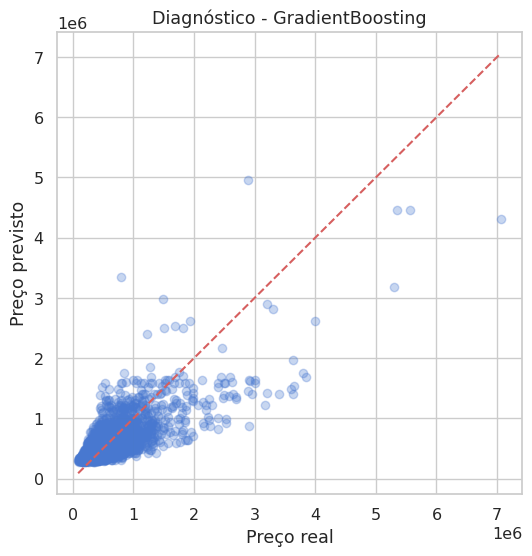

In [ ]:
# PROJETO 2 - Ciência de Dados

!pip install mlflow --quiet

import logging, warnings
warnings.filterwarnings("ignore")
logging.getLogger("mlflow").setLevel(logging.ERROR)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

import mlflow
import mlflow.sklearn

sns.set(style="whitegrid", palette="muted", font_scale=1.05)
np.random.seed(42)

urls = [
    "https://raw.githubusercontent.com/ryanleeallred/datasets/master/kc_house_data.csv",
    "https://raw.githubusercontent.com/harlfoxem/housesalesprediction/master/kc_house_data.csv"
]

df, fonte = None, None
for u in urls:
    try:
        df = pd.read_csv(u)
        fonte = u
        break
    except Exception:
        continue

if df is None:
    raise RuntimeError("Falha ao baixar o dataset em todas as fontes de fallback.")

print("Fonte carregada:", fonte)
print("Shape bruto:", df.shape)

FT2_TO_M2 = 0.092903
df = df.rename(columns={
    "price": "preco",
    "sqft_living": "area_ft2",
    "bedrooms": "quartos",
    "bathrooms": "banheiros"
})
df["area_m2"]  = df["area_ft2"] * FT2_TO_M2
df["preco_m2"] = df["preco"] / df["area_m2"]

X = df[["area_m2","quartos","banheiros"]].copy()
y = df["preco"].copy()

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val,   X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
print("Treino:", X_train.shape, "| Val:", X_val.shape, "| Teste:", X_test.shape)

models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
    "SVR": SVR()
}

param_grid = {
    "LinearRegression": {},
    "RandomForest": {
        "n_estimators": [50, 100],
        "max_depth": [5, 10, None]
    },
    "GradientBoosting": {
        "n_estimators": [100, 200],
        "learning_rate": [0.05, 0.1],
        "max_depth": [3, 5]
    },
    "SVR": {
        "C": [1, 10],
        "kernel": ["linear", "rbf"],
        "gamma": ["scale", "auto"]
    }
}

mlflow.set_experiment("Projeto2_Regressao")
mlflow.sklearn.autolog(log_models=True, silent=True)

best_models = {}
val_rows = []

for name, model in models.items():
    print(f"\nTreinando {name}...")
    gs = GridSearchCV(
        estimator=model,
        param_grid=param_grid[name],
        scoring="neg_mean_squared_error",
        cv=3,
        n_jobs=-1
    )
    gs.fit(X_train, y_train)

    best_model = gs.best_estimator_
    y_pred_val = best_model.predict(X_val)

    rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))
    r2_val   = r2_score(y_val, y_pred_val)

    print(f"Melhores params: {gs.best_params_}")
    print(f"Val RMSE: {rmse_val:.2f} | R²: {r2_val:.3f}")

    best_models[name] = best_model
    val_rows.append({
        "Modelo": name,
        "Melhores_Params": gs.best_params_,
        "RMSE_val": rmse_val,
        "R2_val": r2_val
    })

df_val_results = pd.DataFrame(val_rows).sort_values("RMSE_val")
print("\n--- Resultados de Validação ---")
print(df_val_results)

test_rows = []
for name, model in best_models.items():
    y_pred_test = model.predict(X_test)
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2_test   = r2_score(y_test, y_pred_test)
    test_rows.append({"Modelo": name, "RMSE_test": rmse_test, "R2_test": r2_test})

df_test_results = pd.DataFrame(test_rows).sort_values("RMSE_test")
print("\n--- Resultados no Teste ---")
print(df_test_results)

best_name = df_test_results.iloc[0]["Modelo"]
print("\nMelhor modelo geral:", best_name)

best = best_models[best_name]
y_pred = best.predict(X_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Preço real")
plt.ylabel("Preço previsto")
plt.title(f"Diagnóstico - {best_name}")
plt.show()


Treino: (12967, 6) Val: (4323, 6) Teste: (4323, 6)

--- Validação ---
Melhores params: {'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 200}
Val RMSE: 261162.71 | R²: 0.479

--- Teste ---
RMSE: 280352.51 | R²: 0.532


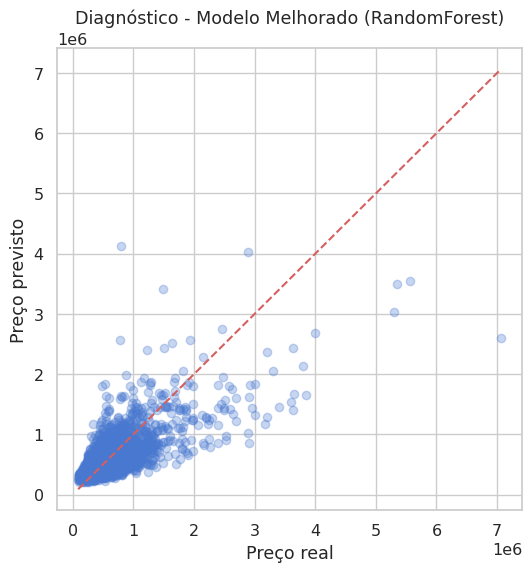

In [ ]:
# PROJETO 2 - Ciência de Dados (Melhoria)

!pip install mlflow --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

import mlflow
import mlflow.sklearn

sns.set(style="whitegrid", palette="muted", font_scale=1.05)
np.random.seed(42)

url = "https://raw.githubusercontent.com/ryanleeallred/datasets/master/kc_house_data.csv"
df = pd.read_csv(url)

FT2_TO_M2 = 0.092903
df = df.rename(columns={
    "price": "preco",
    "sqft_living": "area_ft2",
    "bedrooms": "quartos",
    "bathrooms": "banheiros"
})
df["area_m2"] = df["area_ft2"] * FT2_TO_M2
df["preco_m2"] = df["preco"] / df["area_m2"]

df["quartos2"] = df["quartos"] ** 2
df["banheiros2"] = df["banheiros"] ** 2
df["quartos_banheiros"] = df["quartos"] * df["banheiros"]

X = df[["area_m2", "quartos", "banheiros", "quartos2", "banheiros2", "quartos_banheiros"]]
y = df["preco"]

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val,   X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print("Treino:", X_train.shape, "Val:", X_val.shape, "Teste:", X_test.shape)

model = RandomForestRegressor(random_state=42)

param_grid = {
    "n_estimators": [200, 300],
    "max_depth": [10, 20, None],
    "max_features": ["auto", "sqrt"]
}

gs = GridSearchCV(model, param_grid, scoring="neg_mean_squared_error", cv=3, n_jobs=-1)
gs.fit(X_train, y_train)

best_model = gs.best_estimator_
y_pred_val = best_model.predict(X_val)

rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))
r2_val   = r2_score(y_val, y_pred_val)

print("\n--- Validação ---")
print("Melhores params:", gs.best_params_)
print(f"Val RMSE: {rmse_val:.2f} | R²: {r2_val:.3f}")

y_pred_test = best_model.predict(X_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_test   = r2_score(y_test, y_pred_test)

print("\n--- Teste ---")
print(f"RMSE: {rmse_test:.2f} | R²: {r2_test:.3f}")

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_test, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Preço real")
plt.ylabel("Preço previsto")
plt.title("Diagnóstico - Modelo Melhorado (RandomForest)")
plt.show()


Fonte: https://raw.githubusercontent.com/ryanleeallred/datasets/master/kc_house_data.csv | shape: (21613, 21)

Treinando RandomForest...
Melhores params: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 400}
Val RMSE: 149729.30 | R²: 0.829

Treinando GradientBoosting...
Melhores params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 400}
Val RMSE: 138838.12 | R²: 0.853

--- Validação ---
             Modelo                                    Melhores_Params  \
1  GradientBoosting  {'learning_rate': 0.1, 'max_depth': 3, 'n_esti...   
0      RandomForest  {'max_depth': None, 'max_features': 'sqrt', 'n...   

        RMSE_val    R2_val  
1  138838.122792  0.852749  
0  149729.302034  0.828741  

--- Teste ---
             Modelo      RMSE_test   R2_test
1  GradientBoosting  132729.496060  0.895149
0      RandomForest  167906.896725  0.832207

Melhor modelo geral: GradientBoosting


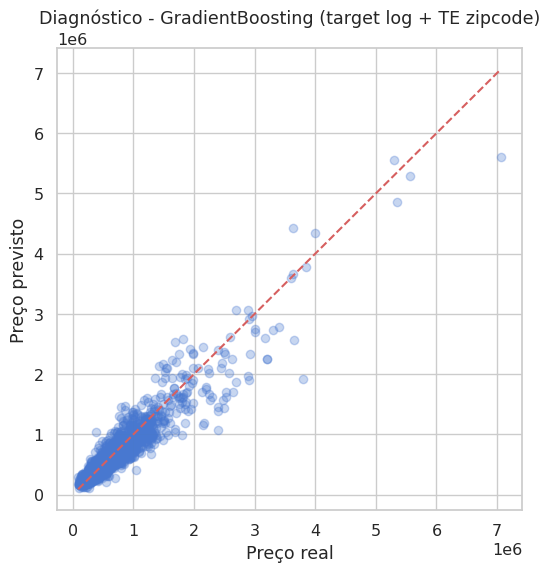

In [ ]:

# PROJETO 2 - Ciência de Dados (Melhoria 2)

!pip install mlflow --quiet

import warnings, logging
warnings.filterwarnings("ignore")
logging.getLogger("mlflow").setLevel(logging.ERROR)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

import mlflow
import mlflow.sklearn

sns.set(style="whitegrid", palette="muted", font_scale=1.05)
np.random.seed(42)

urls = [
    "https://raw.githubusercontent.com/ryanleeallred/datasets/master/kc_house_data.csv",
    "https://raw.githubusercontent.com/harlfoxem/housesalesprediction/master/kc_house_data.csv"
]
df, fonte = None, None
for u in urls:
    try:
        df = pd.read_csv(u)
        fonte = u
        break
    except Exception:
        pass
if df is None:
    raise RuntimeError("Falha ao baixar o dataset.")
print("Fonte:", fonte, "| shape:", df.shape)

FT2_TO_M2 = 0.092903
df = df.rename(columns={
    "price": "preco",
    "sqft_living": "area_ft2",
    "bedrooms": "quartos",
    "bathrooms": "banheiros",
    "zipcode": "zipcode"
})
df["area_m2"] = df["area_ft2"] * FT2_TO_M2

base_cols = ["preco","area_m2","quartos","banheiros","zipcode",
             "grade","condition","view","waterfront","floors","sqft_lot","yr_built"]
for c in base_cols:
    if c not in df.columns:
        df[c] = np.nan

df_model = df[base_cols].copy()

num_cols = [c for c in df_model.columns if c != "zipcode"]
for c in num_cols:
    df_model[c] = pd.to_numeric(df_model[c], errors="coerce")
df_model[num_cols] = df_model[num_cols].fillna(df_model[num_cols].median())
df_model["zipcode"] = df_model["zipcode"].astype(str).fillna("unknown")

X_all = df_model.drop(columns=["preco"])
y_all = df_model["preco"]

X_train, X_temp, y_train, y_temp = train_test_split(X_all, y_all, test_size=0.4, random_state=42)
X_val,   X_test, y_val, y_test  = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

mean_global = y_train.mean()
enc_map = y_train.groupby(X_train["zipcode"]).mean()
def apply_target_enc(series_zip):
    return series_zip.map(enc_map).fillna(mean_global)

X_train = X_train.copy()
X_val   = X_val.copy()
X_test  = X_test.copy()

X_train["te_zipcode"] = apply_target_enc(X_train["zipcode"])
X_val["te_zipcode"]   = apply_target_enc(X_val["zipcode"])
X_test["te_zipcode"]  = apply_target_enc(X_test["zipcode"])

X_train = X_train.drop(columns=["zipcode"])
X_val   = X_val.drop(columns=["zipcode"])
X_test  = X_test.drop(columns=["zipcode"])

y_train_log = np.log1p(y_train)
y_val_log   = np.log1p(y_val)
y_test_log  = np.log1p(y_test)

models = {
    "RandomForest": RandomForestRegressor(random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42)
}
param_grid = {
    "RandomForest": {
        "n_estimators": [200, 400],      # 1
        "max_depth": [10, None],         # 2
        "max_features": ["sqrt","log2"]  # 3
    },
    "GradientBoosting": {
        "n_estimators": [200, 400],      # 1
        "learning_rate": [0.05, 0.1],    # 2
        "max_depth": [3, 5]              # 3
    }
}

mlflow.set_experiment("Projeto2_Regressao_Melhoria")
mlflow.sklearn.autolog(log_models=True, silent=True)

best_models = {}
val_rows = []
for name, model in models.items():
    print(f"\nTreinando {name}...")
    gs = GridSearchCV(
        estimator=model,
        param_grid=param_grid[name],
        scoring="neg_mean_squared_error",
        cv=3,
        n_jobs=-1
    )
    gs.fit(X_train, y_train_log)

    best_model = gs.best_estimator_
    y_pred_val_log = best_model.predict(X_val)

    y_pred_val = np.expm1(y_pred_val_log)
    rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))
    r2_val   = r2_score(y_val, y_pred_val)

    print("Melhores params:", gs.best_params_)
    print(f"Val RMSE: {rmse_val:.2f} | R²: {r2_val:.3f}")

    best_models[name] = best_model
    val_rows.append({
        "Modelo": name,
        "Melhores_Params": gs.best_params_,
        "RMSE_val": rmse_val,
        "R2_val": r2_val
    })

df_val = pd.DataFrame(val_rows).sort_values("RMSE_val")
print("\n--- Validação ---")
print(df_val)

test_rows = []
for name, model in best_models.items():
    y_pred_test_log = model.predict(X_test)
    y_pred_test = np.expm1(y_pred_test_log)
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2_test   = r2_score(y_test, y_pred_test)
    test_rows.append({"Modelo": name, "RMSE_test": rmse_test, "R2_test": r2_test})

df_test = pd.DataFrame(test_rows).sort_values("RMSE_test")
print("\n--- Teste ---")
print(df_test)

best_name = df_test.iloc[0]["Modelo"]
print("\nMelhor modelo geral:", best_name)

best = best_models[best_name]
y_pred = np.expm1(best.predict(X_test))

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Preço real")
plt.ylabel("Preço previsto")
plt.title(f"Diagnóstico - {best_name} (target log + TE zipcode)")
plt.show()


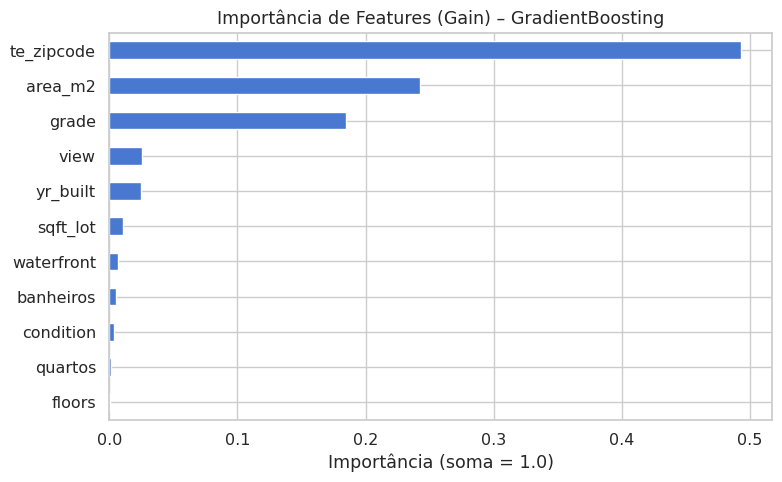

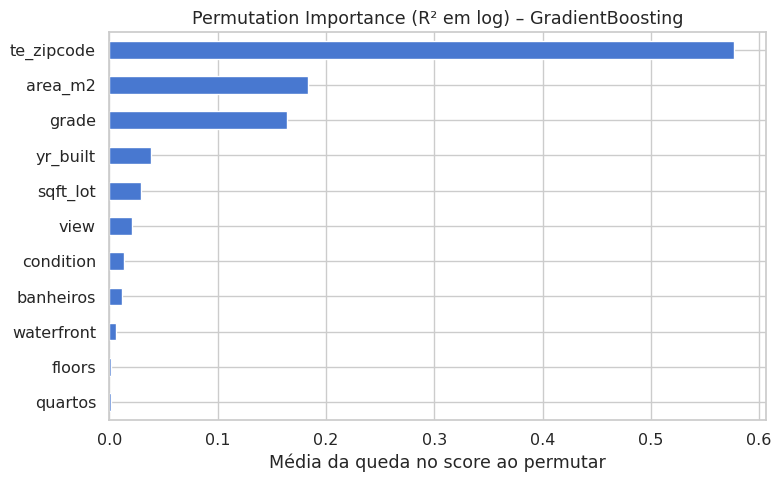

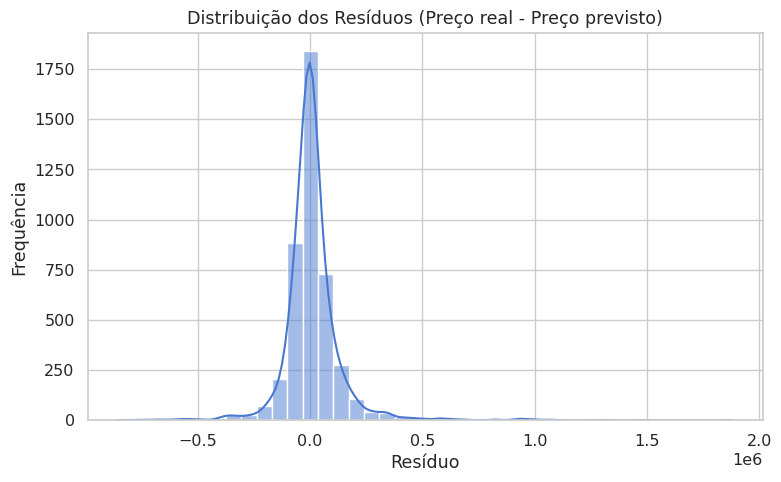

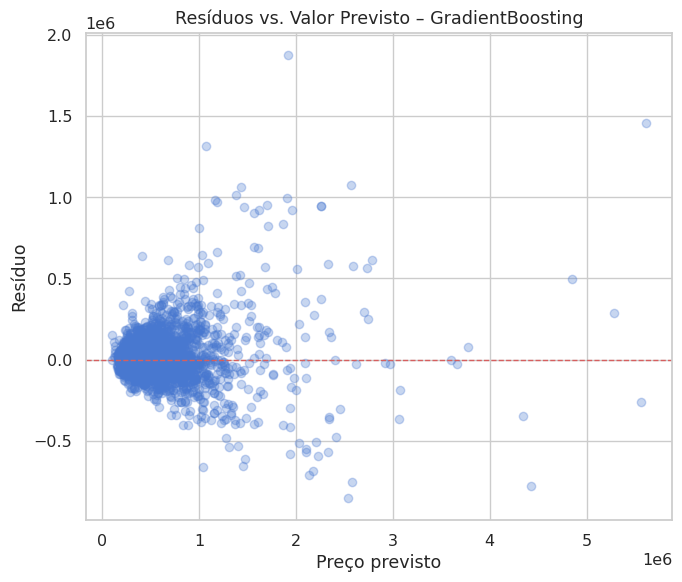

In [ ]:
# IMPORTÂNCIA DE FEATURES + DIAGNÓSTICO DE RESÍDUOS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.inspection import permutation_importance

gb = best_models.get("GradientBoosting", None)
if gb is None:
    raise RuntimeError("GradientBoosting não está em best_models. Verifique a célula anterior.")

feat_names = list(X_train.columns)
gain_imp = pd.Series(gb.feature_importances_, index=feat_names).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
gain_imp.plot(kind="barh")
plt.title("Importância de Features (Gain) – GradientBoosting")
plt.xlabel("Importância (soma = 1.0)")
plt.tight_layout()
plt.show()

y_test_log_local = np.log1p(y_test)

perm = permutation_importance(
    gb,
    X_test,
    y_test_log_local,
    scoring="r2",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)
perm_imp = pd.Series(perm.importances_mean, index=feat_names).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
perm_imp.plot(kind="barh")
plt.title("Permutation Importance (R² em log) – GradientBoosting")
plt.xlabel("Média da queda no score ao permutar")
plt.tight_layout()
plt.show()

y_pred_test_log = gb.predict(X_test)
y_pred_test_lin = np.expm1(y_pred_test_log)
residuos = y_test - y_pred_test_lin

plt.figure(figsize=(8,5))
sns.histplot(residuos, bins=40, kde=True)
plt.title("Distribuição dos Resíduos (Preço real - Preço previsto)")
plt.xlabel("Resíduo")
plt.ylabel("Frequência")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,6))
plt.scatter(y_pred_test_lin, residuos, alpha=0.3)
plt.axhline(0, color="r", linestyle="--", linewidth=1)
plt.title("Resíduos vs. Valor Previsto – GradientBoosting")
plt.xlabel("Preço previsto")
plt.ylabel("Resíduo")
plt.tight_layout()
plt.show()
